<a href="https://colab.research.google.com/github/Bishal2211/Simulation_and_Modeling_Lab/blob/main/Restaurant_Competitive_Performance_Simulation/Smart_Restaurant_Service_Efficiency_and_Customer_Experience_Simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name : Ismam Ahmed<br>
Id : 0432220005101116

Name : Tamanna Khokon<br>
Id : 0432310005101082

Name : Tasnim Jahan<br>
Id : 0432310005101089<br>
Section : 7B<br>
course code: CSE 413 <br>
Course  : Simulation and modeling

# Restaurant Competitive Performance Simulation Using Statistical Analysis

## Simulation and Modeling Lab Project

This project simulates a custom restaurant system and compares it with a KFC-inspired benchmark restaurant using statistical analysis, customer satisfaction analysis, customer mood analysis, and two-sample t-test evaluation.

In [53]:
# Import Libraries
import random                    # Random simulation
import pandas as pd              # Data analysis
import matplotlib.pyplot as plt  # Graph visualization
from scipy.stats import ttest_ind # Two-sample t-test

# Restaurant Datasets

Two restaurant systems are used:

1. Custom Restaurant → Random simulated data
2. KFC-inspired Benchmark → Fixed benchmark data

In [54]:
# Custom Restaurant Menu
my_restaurant_menu = {

    "Burger": 250,
    "Pizza": 500,
    "Pasta": 350,
    "Coffee": 120,
    "Fried Chicken": 400
}

# KFC-Inspired Benchmark Dataset
kfc_data = {

    "Waiting Times": [5, 6, 7, 6, 5, 7, 8, 6, 5, 7],

    "Food Quality": 8,

    "Food Cost": 5,

    "Customer Mood": 7,

    "Customer Satisfaction": 8
}

# Customer Simulation Model

Each customer receives:
- random food orders
- total bill
- waiting time
- satisfaction level
- customer mood

In [55]:
# Customer Class
class Customer:

    def __init__(self, customer_id):

        self.customer_id = customer_id

        # Random Food Order
        self.items = random.sample(
            list(my_restaurant_menu.keys()),
            random.randint(1, 2)
        )

        # Total Bill Calculation
        self.total_bill = sum(
            my_restaurant_menu[item]
            for item in self.items
        )

        # Random Waiting Time
        self.waiting_time = random.randint(5, 15)

        # Food Quality Score
        self.food_quality = random.randint(6, 10)

        # Food Cost Score
        if self.total_bill <= 300:

            self.food_cost_score = 9

        elif self.total_bill <= 600:

            self.food_cost_score = 7

        else:

            self.food_cost_score = 5

        # Satisfaction Level
        if self.waiting_time <= 8:

            self.satisfaction = "High"

        elif self.waiting_time <= 12:

            self.satisfaction = "Medium"

        else:

            self.satisfaction = "Low"

        # Customer Mood System
        if self.waiting_time <= 8 and self.food_quality >= 8:

            self.mood = "Happy"

        elif self.waiting_time <= 12:

            self.mood = "Neutral"

        else:

            self.mood = "Angry"

# Restaurant Simulation

This function generates restaurant customers and displays customer information.

In [56]:
# Simulation Function
def restaurant_simulation(total_customers):

    customers = []

    for i in range(1, total_customers + 1):

        customer = Customer(i)

        customers.append(customer)

        print("\nCustomer ID:", customer.customer_id)

        print("Ordered Items:", customer.items)

        print("Bill Amount:", customer.total_bill)

        print("Waiting Time:", customer.waiting_time)

        print("Satisfaction:", customer.satisfaction)

        print("Customer Mood:", customer.mood)

        print("-" * 30)

    return customers

# Statistical Analysis

This section analyzes:
- average waiting time
- average bill amount
- customer satisfaction
- customer mood

In [57]:
# Analysis Function
def generate_analysis(customers):

    customer_ids = []
    bills = []
    waiting_times = []
    satisfactions = []
    moods = []
    food_quality_scores = []
    food_cost_scores = []

    for customer in customers:

        customer_ids.append(customer.customer_id)

        bills.append(customer.total_bill)

        waiting_times.append(customer.waiting_time)

        satisfactions.append(customer.satisfaction)

        moods.append(customer.mood)

        food_quality_scores.append(
            customer.food_quality
        )

        food_cost_scores.append(
            customer.food_cost_score
        )

    # Create DataFrame
    df = pd.DataFrame({

        "Customer ID": customer_ids,

        "Bill Amount": bills,

        "Waiting Time": waiting_times,

        "Satisfaction": satisfactions,

        "Mood": moods,

        "Food Quality": food_quality_scores,

        "Food Cost Score": food_cost_scores
    })

    print("\nCustom Restaurant Dataset")

    print(df)

    # Average Analysis
    print("\nAverage Waiting Time:",
          round(df["Waiting Time"].mean(), 2))

    print("Average Bill Amount:",
          round(df["Bill Amount"].mean(), 2))

    print("Average Food Quality:",
          round(df["Food Quality"].mean(), 2))

    # Satisfaction Count
    print("\nCustomer Satisfaction Count")

    print(df["Satisfaction"].value_counts())

    # Mood Count
    print("\nCustomer Mood Count")

    print(df["Mood"].value_counts())

    return df

# Data Visualization

Graphs are used to visualize restaurant performance and customer behavior.

In [58]:
# Visualization Function
def generate_charts(df):

    # Waiting Time Chart
    plt.figure(figsize=(8,5))

    plt.plot(df["Customer ID"],
             df["Waiting Time"],
             marker='o')

    plt.title("Custom Restaurant Waiting Time")

    plt.xlabel("Customer ID")

    plt.ylabel("Waiting Time")

    plt.grid(True)

    plt.show()

    # Bill Amount Chart
    plt.figure(figsize=(8,5))

    plt.bar(df["Customer ID"],
            df["Bill Amount"])

    plt.title("Customer Bill Analysis")

    plt.xlabel("Customer ID")

    plt.ylabel("Bill Amount")

    plt.show()

# Restaurant Comparison System

This section compares the custom restaurant with the KFC-inspired benchmark system using statistical analysis and overall restaurant performance scoring.

In [59]:
# Restaurant Performance Score

def calculate_restaurant_score(df):

    # My Restaurant Scores

    waiting_score = 10 - (
        df["Waiting Time"].mean() / 2
    )

    quality_score = df["Food Quality"].mean()

    cost_score = df["Food Cost Score"].mean()

    # Satisfaction Score
    satisfaction_score = 0

    satisfaction_counts = (
        df["Satisfaction"]
        .value_counts()
    )

    if "High" in satisfaction_counts:

        satisfaction_score = (
            satisfaction_counts["High"]
            / len(df)
        ) * 10

    # Mood Score
    mood_score = 0

    mood_counts = (
        df["Mood"]
        .value_counts()
    )

    if "Happy" in mood_counts:

        mood_score = (
            mood_counts["Happy"]
            / len(df)
        ) * 10

    # Final Restaurant Score
    my_final_score = (

        waiting_score +
        quality_score +
        cost_score +
        satisfaction_score +
        mood_score

    ) / 5

    # KFC Benchmark Score
    kfc_waiting_average = (
        sum(kfc_data["Waiting Times"])
        / len(kfc_data["Waiting Times"])
    )

    kfc_final_score = (

        kfc_waiting_average +
        kfc_data["Food Quality"] +
        kfc_data["Food Cost"] +
        kfc_data["Customer Mood"] +
        kfc_data["Customer Satisfaction"]

    ) / 5

    # Two-Sample T-Test
    t_stat, p_value = ttest_ind(

        df["Waiting Time"],

        kfc_data["Waiting Times"]
    )

    print("\n===================================")

    print(" RESTAURANT COMPARISON ")

    print("===================================")

    print("\nMy Restaurant Score:",
          round(my_final_score, 2))

    print("KFC Benchmark Score:",
          round(kfc_final_score, 2))

    print("\nT-Test P-Value:",
          round(p_value, 4))

    # Final Comparison
    if my_final_score > kfc_final_score:

        print("\nConclusion:")

        print("In this simulation scenario,")

        print("the custom restaurant")

        print("outperformed the KFC-inspired")

        print("benchmark system.")

        print("Better affordability,")

        print("food quality, customer")

        print("mood, and customer")

        print("experience made the")

        print("restaurant more attractive.")

    else:

        print("\nConclusion:")

        print("The KFC-inspired benchmark")

        print("performed better in this")

        print("simulation scenario.")

        print("The custom restaurant")

        print("needs improvements in")

        print("service quality and")

        print("customer experience.")

# Main Program

This section runs the complete restaurant simulation and comparison system.

 RESTAURANT SIMULATION SYSTEM 
Enter Number of Customers: 10

Customer ID: 1
Ordered Items: ['Pizza']
Bill Amount: 500
Waiting Time: 6
Satisfaction: High
Customer Mood: Happy
------------------------------

Customer ID: 2
Ordered Items: ['Pizza', 'Fried Chicken']
Bill Amount: 900
Waiting Time: 6
Satisfaction: High
Customer Mood: Neutral
------------------------------

Customer ID: 3
Ordered Items: ['Coffee', 'Pasta']
Bill Amount: 470
Waiting Time: 5
Satisfaction: High
Customer Mood: Neutral
------------------------------

Customer ID: 4
Ordered Items: ['Pizza']
Bill Amount: 500
Waiting Time: 12
Satisfaction: Medium
Customer Mood: Neutral
------------------------------

Customer ID: 5
Ordered Items: ['Fried Chicken', 'Burger']
Bill Amount: 650
Waiting Time: 7
Satisfaction: High
Customer Mood: Neutral
------------------------------

Customer ID: 6
Ordered Items: ['Coffee']
Bill Amount: 120
Waiting Time: 7
Satisfaction: High
Customer Mood: Happy
------------------------------

Customer ID

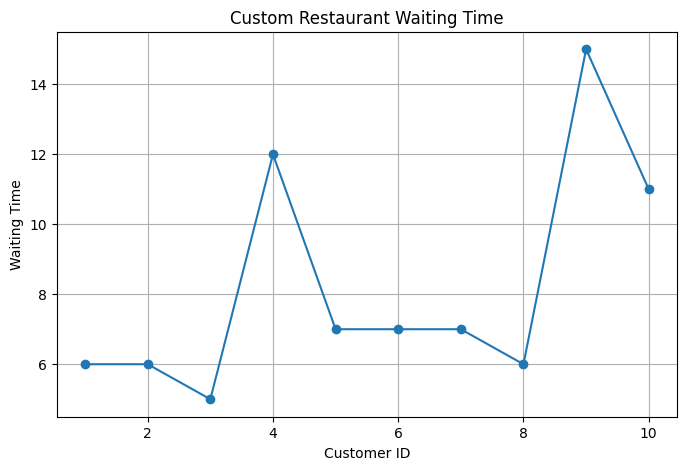

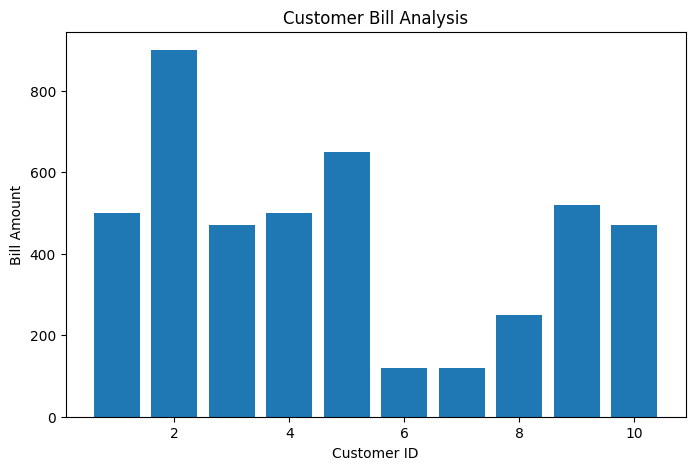


 RESTAURANT COMPARISON 

My Restaurant Score: 6.24
KFC Benchmark Score: 6.84

T-Test P-Value: 0.0835

Conclusion:
The KFC-inspired benchmark
performed better in this
simulation scenario.
The custom restaurant
needs improvements in
service quality and
customer experience.

Simulation Completed Successfully


In [60]:
# Main Program

print("===================================")

print(" RESTAURANT SIMULATION SYSTEM ")

print("===================================")

# User Input
total_customers = int(
    input("Enter Number of Customers: ")
)

# Run Simulation
customers = restaurant_simulation(
    total_customers
)

# Generate Analysis
df = generate_analysis(customers)

# Generate Graphs
generate_charts(df)

# Final Restaurant Comparison
calculate_restaurant_score(df)

print("\nSimulation Completed Successfully")

# Conclusion

This project simulated and compared a custom restaurant system with a KFC-inspired benchmark restaurant using statistical analysis and simulation modeling.

The system analyzed:
- waiting time
- food quality
- food affordability
- customer mood
- customer satisfaction

The simulation dynamically generated different restaurant scenarios using random customer behavior. In some simulation runs, the custom restaurant outperformed the benchmark system due to better affordability, food quality, and customer experience.

The project demonstrates how simulation and statistical analysis can be used to evaluate restaurant performance and customer behavior in real-world business environments.